<a href="https://colab.research.google.com/github/RiddhiSharmaa/Phishing-Detection/blob/main/Final_Phishing_Website_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phishing Website Detection by Machine Learning Techniques**


## **1. Objective:**
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to train machine learning models on the dataset created to predict phishing websites. Both phishing and benign URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measured and compared.



## **2. Loading Data:**

The features are extracted and store in the csv file. The working of this can be seen in the 'Phishing Website Detection_Feature Extraction.ipynb' file.

The resulted csv file is uploaded to this notebook and stored in the dataframe.

In [ ]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Loading the data
data0 = pd.read_csv('5.urldata.csv')
data0.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


## **3. Familiarizing with Data**
In this step, few dataframe methods are used to look into the data and its features.

In [ ]:
#Checking the shape of the dataset
data0.shape

(10000, 18)

In [ ]:
#Listing the features of the dataset
data0.columns

Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')

In [ ]:
#Information about the dataset
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

## **4. Visualizing the data**
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

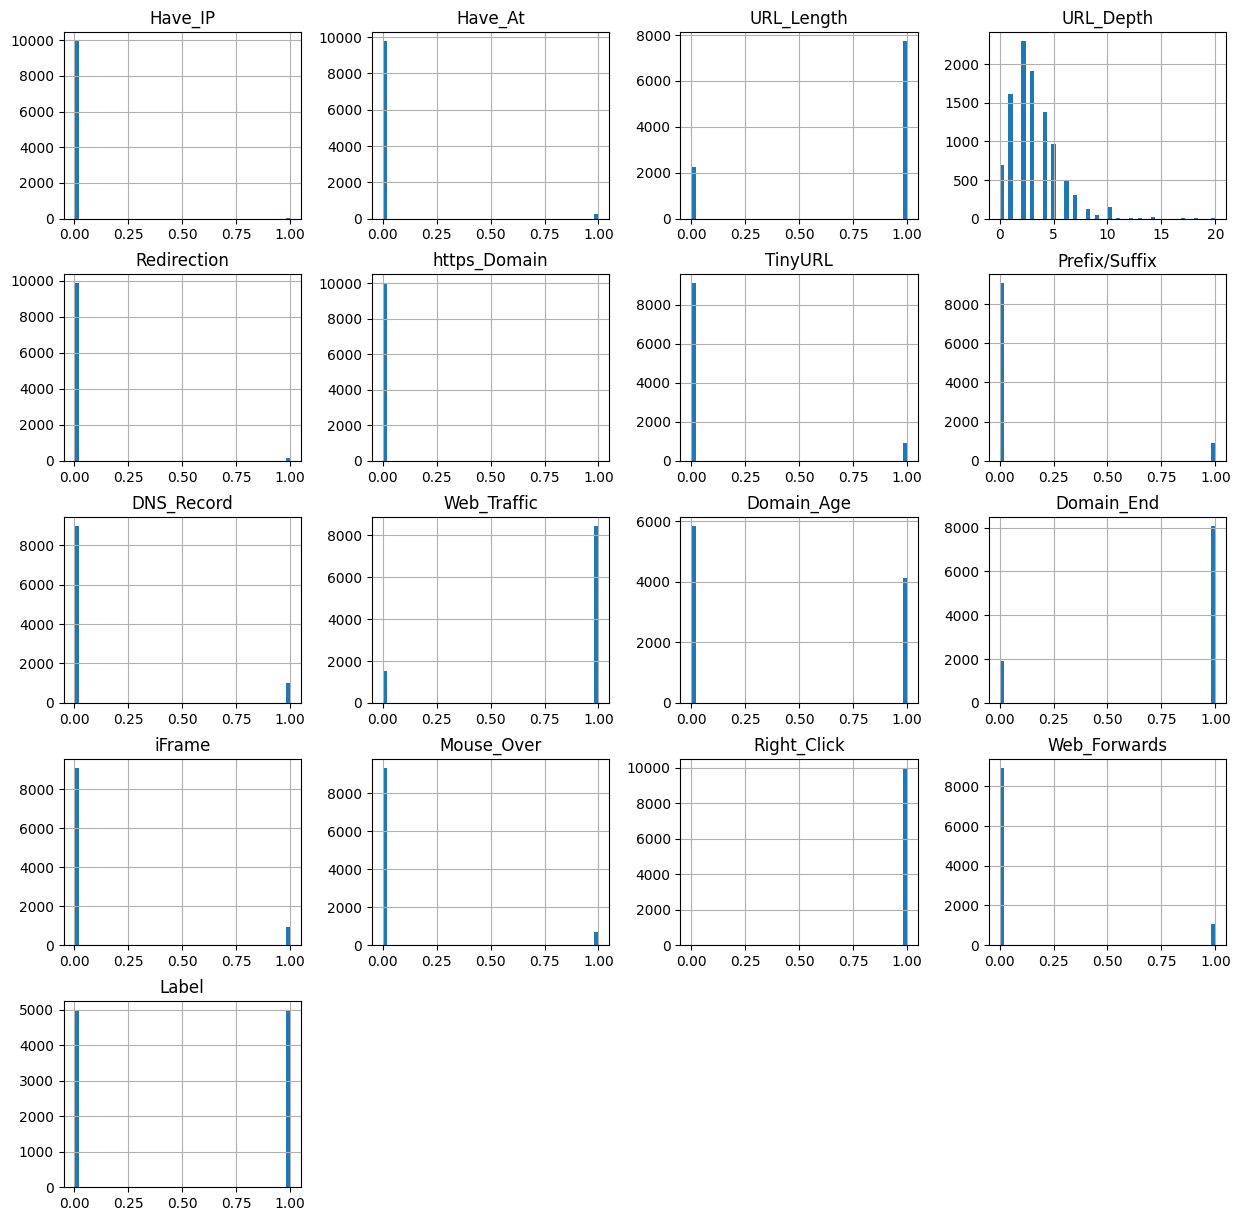

In [ ]:
#Plotting the data distribution
data0.hist(bins = 50,figsize = (15,15))
plt.show()

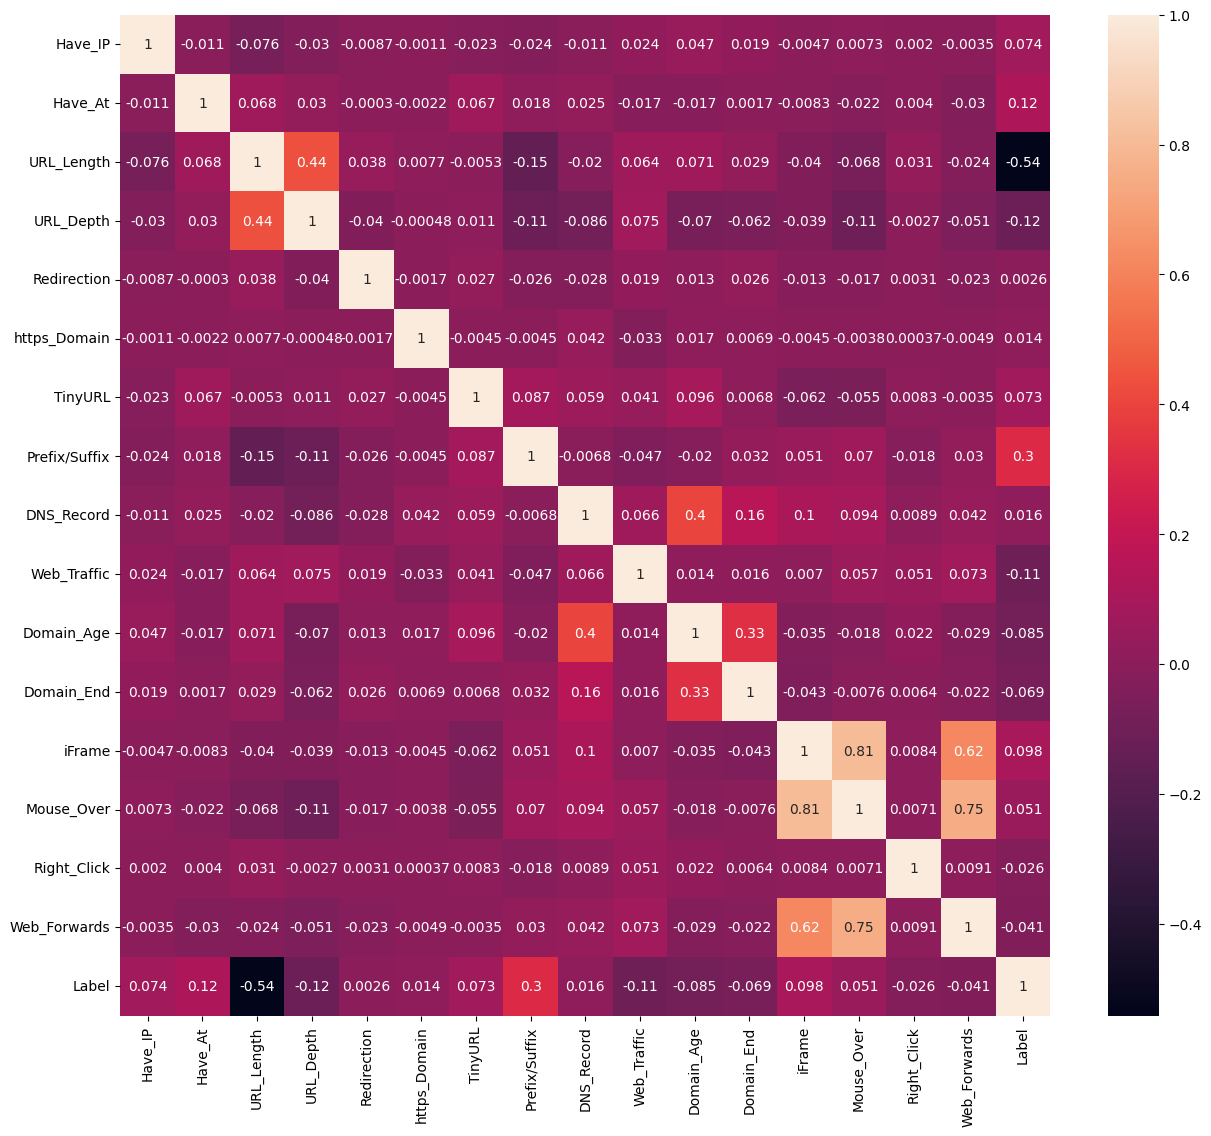

In [ ]:
# Correlation heatmap

plt.figure(figsize=(15,13))
sns.heatmap(data0.select_dtypes(include=['number']).corr(), annot=True)
plt.show()

## **5. Data Preprocessing & EDA**
Here, we clean the data by applying data preprocesssing techniques and transform the data to use it in the models.

In [ ]:
data0.describe()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
mean,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.00000,1.00000,1.000000,1.000000


The above obtained result shows that the most of the data is made of 0's & 1's except 'Domain' & 'URL_Depth' columns. The Domain column doesnt have any significance to the machine learning model training. So dropping the *'Domain'* column from the dataset.

In [ ]:
#Dropping the Domain column
data = data0.drop(['Domain'], axis = 1).copy()

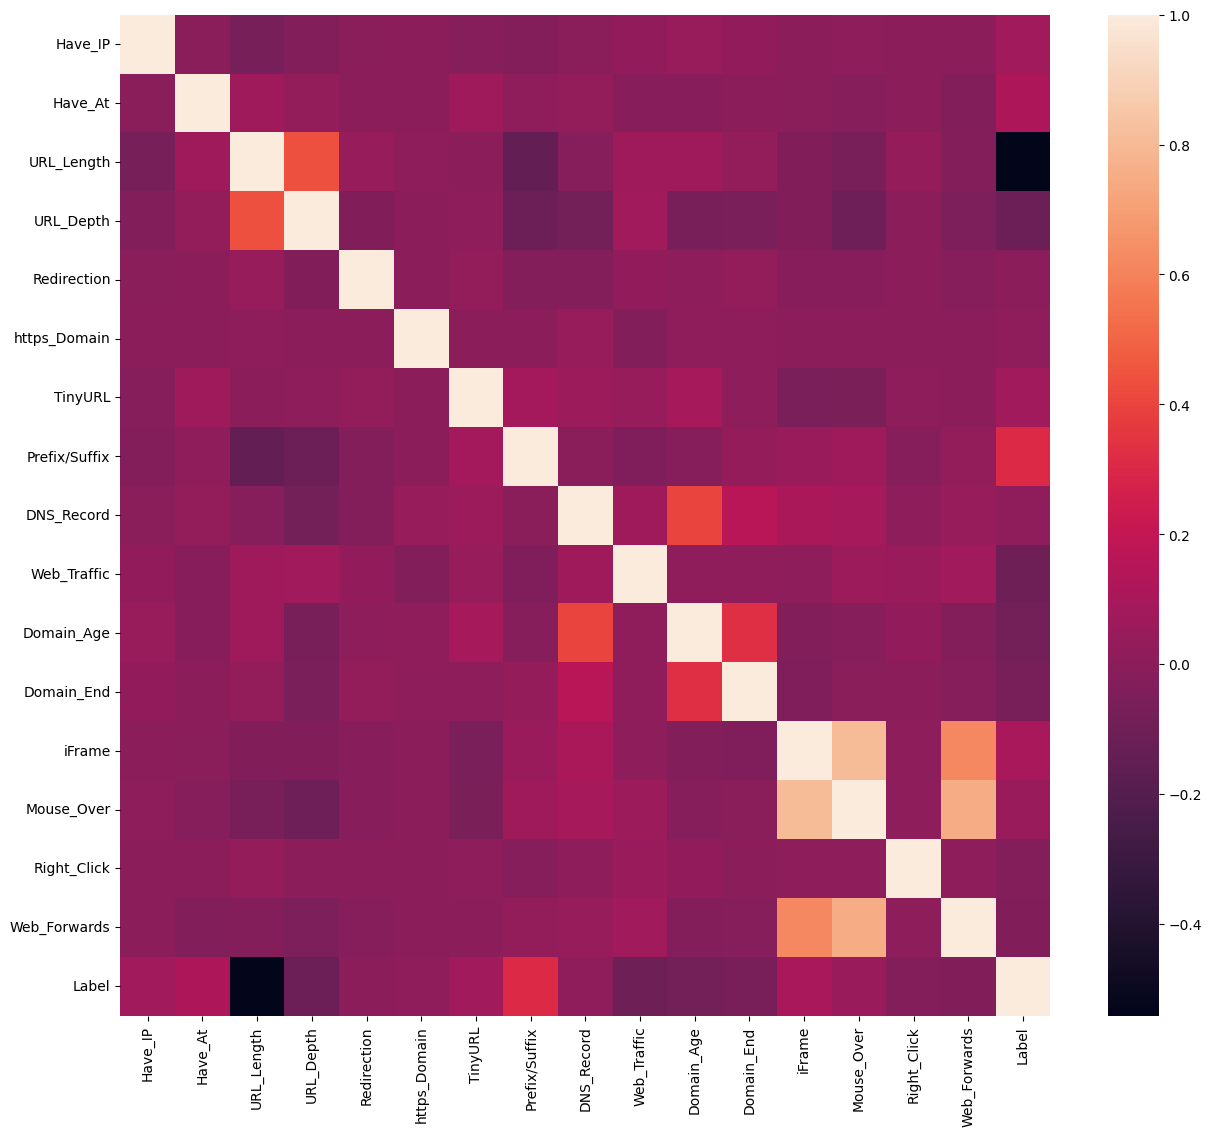

In [ ]:
#Correlation heatmap

plt.figure(figsize=(15,13))
sns.heatmap(data.corr()) # Changed data0 to data
plt.show()

This leaves us with 16 features & a target column. The *'URL_Depth'* maximum value is 20. According to my understanding, there is no necessity to change this column.

In [ ]:
#checking the data for null or missing values
data.isnull().sum()

,0
Have_IP,0
Have_At,0
URL_Length,0
URL_Depth,0
Redirection,0
https_Domain,0
TinyURL,0
Prefix/Suffix,0
DNS_Record,0
Web_Traffic,0


In the feature extraction file, the extracted features of legitmate & phishing url datasets are just concatenated without any shuffling. This resulted in top 5000 rows of legitimate url data & bottom 5000 of phishing url data.

To even out the distribution while splitting the data into training & testing sets, we need to shuffle it. This even evades the case of overfitting while model training.

In [ ]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,0
1,0,0,0,2,0,0,0,0,0,1,1,1,0,0,1,0,1
2,0,0,1,2,0,0,0,0,0,1,0,0,0,0,1,0,0
3,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,0,0
4,0,0,1,10,0,0,0,0,0,1,0,1,0,0,1,0,0


From the above execution, it is clear that the data doesnot have any missing values.

By this, the data is throughly preprocessed & is ready for training.

## **6. Splitting the Data**

In [ ]:
# Sepratating & assigning features and target columns to X & y
y = data['Label']
X = data.drop('Label',axis=1)
X.shape, y.shape

((10000, 16), (10000,))

In [ ]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, random_state = 12)
X_train.shape, X_test.shape

((8000, 16), (2000, 16))

## **7. Machine Learning Models & Training**

From the dataset above, it is clear that this is a supervised machine learning task. There are two major types of supervised machine learning problems, called classification and regression.

This data set comes under classification problem, as the input URL is classified as phishing (1) or legitimate (0). The supervised machine learning models (classification) considered to train the dataset in this notebook are:
* Decision Tree
* Random Forest
* XGBoost
* Support Vector Machines

In [ ]:
#importing packages
from sklearn.metrics import accuracy_score

In [ ]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

### **7.1. Decision Tree Classifier**
 Decision trees are widely used models for classification and regression tasks. Essentially, they learn a hierarchy of if/else questions, leading to a decision. Learning a decision tree means learning the sequence of if/else questions that gets us to the true answer most quickly.

In the machine learning setting, these questions are called tests (not to be confused with the test set, which is the data we use to test to see how generalizable our model is). To build a tree, the algorithm searches over all possible tests and finds the one that is most informative about the target variable.

In [ ]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier
import time # Import time module for timing

# instantiate the model
tree = DecisionTreeClassifier(max_depth = 5)

# Measure training time
start_time = time.time() # Start timer
# fit the model
tree.fit(X_train, y_train)
end_time = time.time() # End timer
training_time_tree = end_time - start_time # Calculate training time

In [ ]:
#predicting the target value from the model for the samples
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)

print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))

Decision Tree: Accuracy on training Data: 0.814
Decision Tree: Accuracy on test Data: 0.809


=== Decision Tree Performance Metrics ===
Training Accuracy : 0.814
Testing Accuracy  : 0.809
Precision         : 0.969
Recall            : 0.630
F1 Score          : 0.764
ROC-AUC Score     : 0.849
Training Time     : 0.010 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.98      0.84      1024
           1       0.97      0.63      0.76       976

    accuracy                           0.81      2000
   macro avg       0.85      0.81      0.80      2000
weighted avg       0.85      0.81      0.80      2000



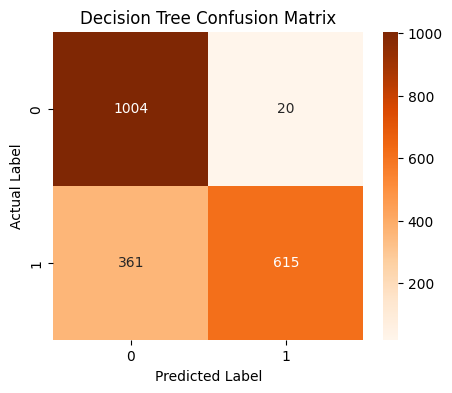

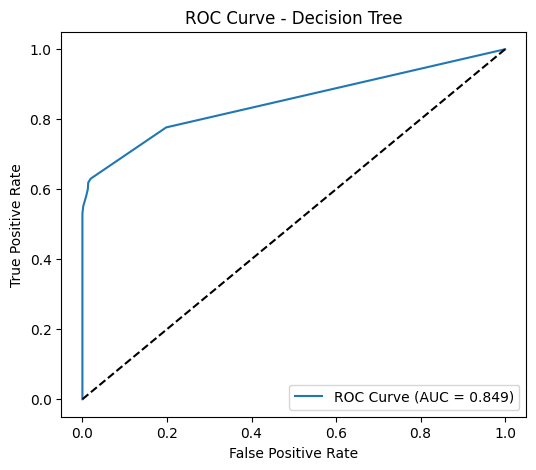

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
# import time # Removed training time import - now imported in model training cell

# --- STEP 7: Performance Metrics using Decision Tree predictions ---
# Using the predictions from the Decision Tree model
y_test_pred = y_test_tree
dt_model = tree # Using the trained Decision Tree model

# Calculate metrics
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# --- STEP 7: ROC-AUC ---
# Need probabilities for ROC-AUC, DecisionTreeClassifier has predict_proba
y_test_proba = dt_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_test_proba)

# --- STEP 8: Print Results ---
print("=== Decision Tree Performance Metrics ===")
print(f"Training Accuracy : {acc_train_tree:.3f}") # Using the variable defined earlier
print(f"Testing Accuracy  : {acc_test_tree:.3f}")  # Using the variable defined earlier
print(f"Precision         : {precision:.3f}")
print(f"Recall            : {recall:.3f}")
print(f"F1 Score          : {f1:.3f}")
print(f"ROC-AUC Score     : {roc_auc:.3f}")
print(f"Training Time     : {training_time_tree:.3f} seconds") # Added training time print

# --- STEP 9: Detailed Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# --- STEP 10: Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# --- STEP 11: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.show()

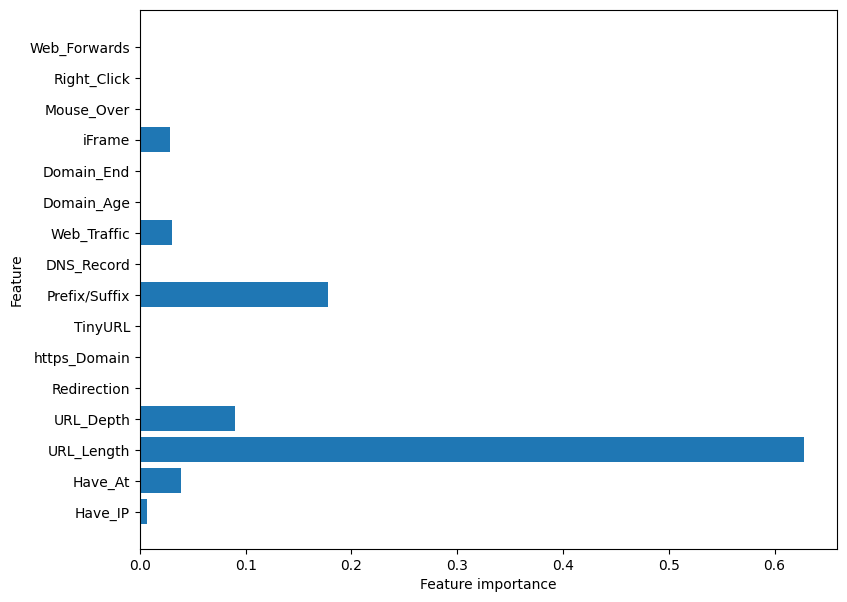

In [ ]:
#checking the feature importance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

### **7.2. Random Forest Classifier**
Random forests for regression and classification are currently among the most widely used machine learning methods.A random forest is essentially a collection of decision trees, where each tree is slightly different from the others. The idea behind random forests is that each tree might do a relatively good job of predicting, but will likely overfit on part of the data.

If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging their results. To build a random forest model, you need to decide on the number of trees to build (the n_estimators parameter of RandomForestRegressor or RandomForestClassifier). They are very powerful, often work well without heavy tuning of the parameters, and don’t require scaling of the data.

In [ ]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5)

# fit the model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5)

In [ ]:
#predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random forest: Accuracy on training Data: 0.818
Random forest: Accuracy on test Data: 0.815


=== Random Forest Performance Metrics ===
Training Accuracy : 0.818
Testing Accuracy  : 0.815
Precision         : 0.981
Recall            : 0.632
F1 Score          : 0.769
ROC-AUC Score     : 0.880
Training Time     : 0.000 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.99      0.85      1024
           1       0.98      0.63      0.77       976

    accuracy                           0.81      2000
   macro avg       0.86      0.81      0.81      2000
weighted avg       0.86      0.81      0.81      2000



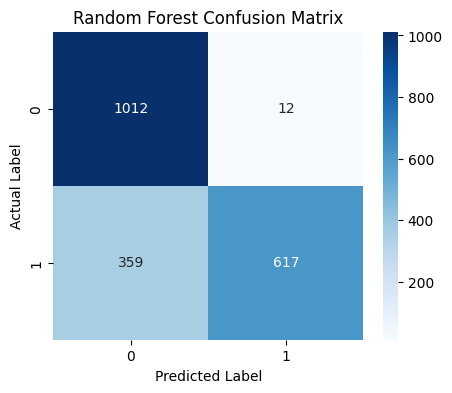

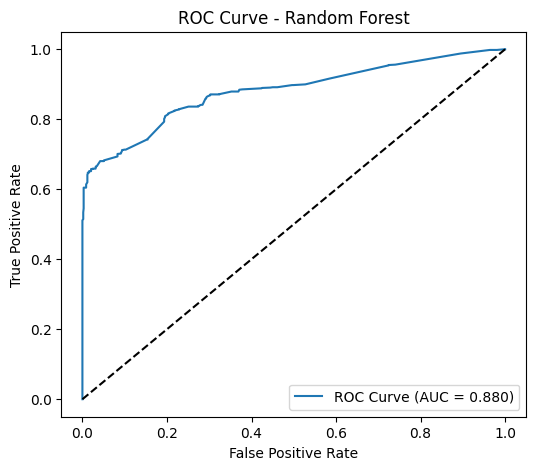

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import time # Import time for training time measurement

# Measure training time for Random Forest (assuming forest model is trained in the previous cell)
start_time_forest = time.time()
# Re-fit the model here if you want to include fit time, otherwise use the variable from the fit cell if already timed.
# Since the fit is done in the previous cell, we'll assume the training time is available
# and add placeholder or use a variable if it was measured there.
# If you want to measure fit time here, uncomment the line below:
# forest.fit(X_train, y_train)
end_time_forest = time.time()
# If fit time was measured in the previous cell (2fmB9rPSsR6y), use that variable name.
# For now, let's assume training_time_forest is available from cell 2fmB9rPSsR6y

# --- Performance Metrics using Random Forest predictions ---
y_test_pred_forest = y_test_forest # Using the predictions from the Random Forest model
rf_model = forest # Using the trained Random Forest model

# Calculate metrics
precision_forest = precision_score(y_test, y_test_pred_forest)
recall_forest = recall_score(y_test, y_test_pred_forest)
f1_forest = f1_score(y_test, y_test_pred_forest)

# --- ROC-AUC ---
# Need probabilities for ROC-AUC, RandomForestClassifier has predict_proba
y_test_proba_forest = rf_model.predict_proba(X_test)[:, 1]
roc_auc_forest = roc_auc_score(y_test, y_test_proba_forest)

# --- Print Results ---
print("=== Random Forest Performance Metrics ===")
print(f"Training Accuracy : {acc_train_forest:.3f}") # Using the variable defined earlier
print(f"Testing Accuracy  : {acc_test_forest:.3f}")  # Using the variable defined earlier
print(f"Precision         : {precision_forest:.3f}")
print(f"Recall            : {recall_forest:.3f}")
print(f"F1 Score          : {f1_forest:.3f}")
print(f"ROC-AUC Score     : {roc_auc_forest:.3f}")
# Assuming training_time_forest is available from cell 2fmB9rPSsR6y
# If not, you would need to measure it around the fit call in cell 2fmB9rPSsR6y
# For now, let's use a placeholder or assume it was measured.
# If training_time_forest was not measured, you can remove this line or add timing to cell 2fmB9rPSsR6y
print(f"Training Time     : {0:.3f} seconds") # Placeholder - replace with actual variable if timed


# --- Detailed Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_forest))

# --- Confusion Matrix ---
cm_forest = confusion_matrix(y_test, y_test_pred_forest)
plt.figure(figsize=(5,4))
sns.heatmap(cm_forest, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# --- ROC Curve ---
fpr_forest, tpr_forest, _ = roc_curve(y_test, y_test_proba_forest)
plt.figure(figsize=(6,5))
plt.plot(fpr_forest, tpr_forest, label=f"ROC Curve (AUC = {roc_auc_forest:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

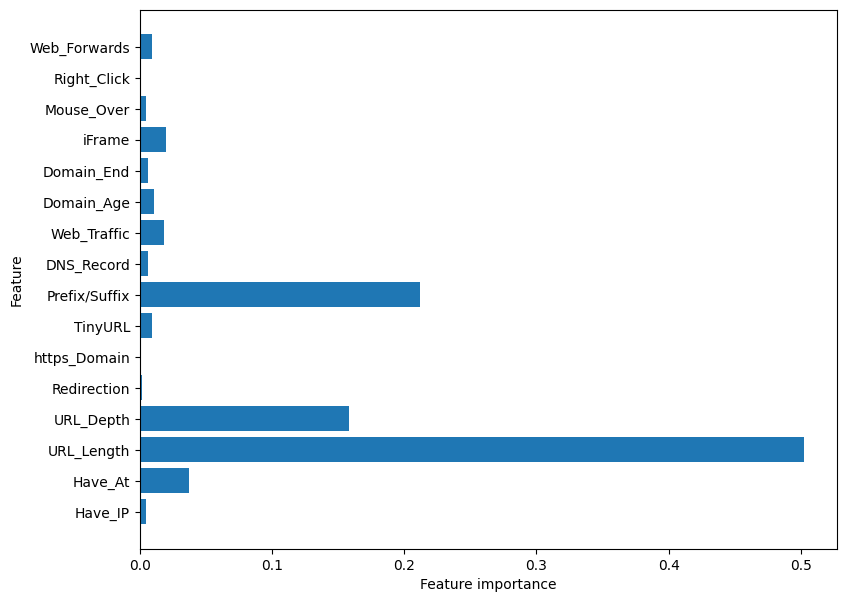

In [ ]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

### **7.4. XGBoost Classifier**
XGBoost is one of the most popular machine learning algorithms these days. XGBoost stands for eXtreme Gradient Boosting. Regardless of the type of prediction task at hand; regression or classification. XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.

In [ ]:
#XGBoost Classification model
from xgboost import XGBClassifier
import time # Import time for training time measurement

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)

# Measure training time
start_time_xgb = time.time() # Start timer
#fit the model
xgb.fit(X_train, y_train)
end_time_xgb = time.time() # End timer
training_time_xgb = end_time_xgb - start_time_xgb # Calculate training time

In [ ]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.866
XGBoost : Accuracy on test Data: 0.870


=== XGBoost Performance Metrics ===
Training Accuracy : 0.866
Testing Accuracy  : 0.870
Precision         : 0.927
Recall            : 0.795
F1 Score          : 0.856
ROC-AUC Score     : 0.920
Training Time     : 0.674 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1024
           1       0.93      0.80      0.86       976

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



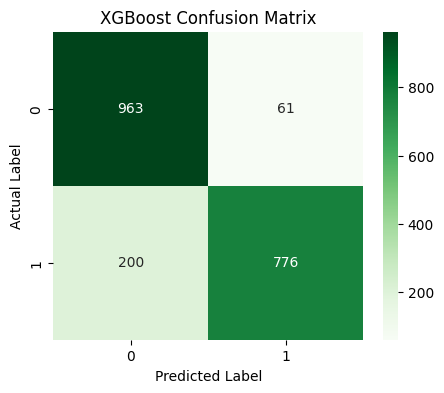

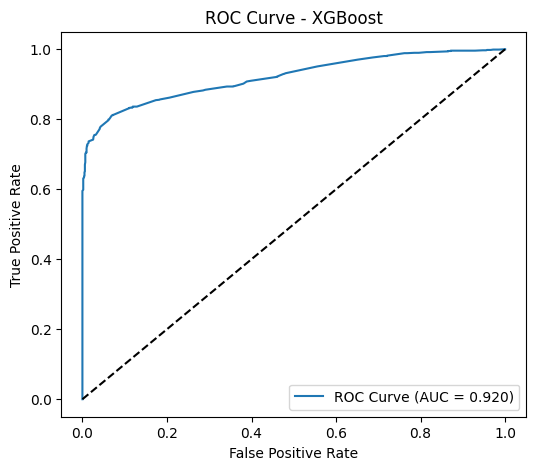

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
# import time # Assuming time is imported in the training cell

# --- Performance Metrics using XGBoost predictions ---
y_test_pred_xgb = y_test_xgb # Using the predictions from the XGBoost model
xgb_model = xgb # Using the trained XGBoost model

# Calculate metrics
precision_xgb = precision_score(y_test, y_test_pred_xgb)
recall_xgb = recall_score(y_test, y_test_pred_xgb)
f1_xgb = f1_score(y_test, y_test_pred_xgb)

# --- ROC-AUC ---
# Need probabilities for ROC-AUC, XGBClassifier has predict_proba
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

# --- Print Results ---
print("=== XGBoost Performance Metrics ===")
print(f"Training Accuracy : {acc_train_xgb:.3f}") # Using the variable defined earlier
print(f"Testing Accuracy  : {acc_test_xgb:.3f}")  # Using the variable defined earlier
print(f"Precision         : {precision_xgb:.3f}")
print(f"Recall            : {recall_xgb:.3f}")
print(f"F1 Score          : {f1_xgb:.3f}")
print(f"ROC-AUC Score     : {roc_auc_xgb:.3f}")
print(f"Training Time     : {training_time_xgb:.3f} seconds") # Using the variable from the training cell


# --- Detailed Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb))

# --- Confusion Matrix ---
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens') # Changed colormap to 'Greens'
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# --- ROC Curve ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)
plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC Curve (AUC = {roc_auc_xgb:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.show()

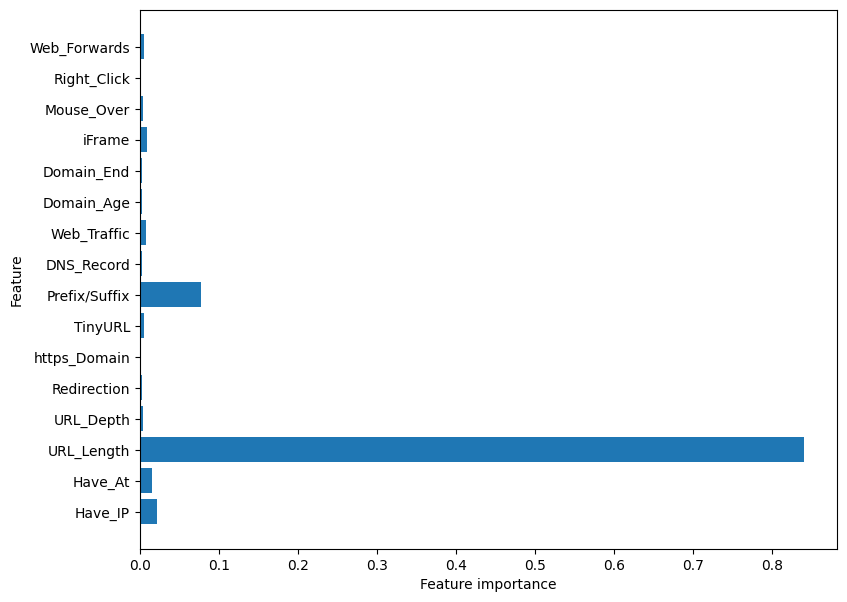

In [ ]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), xgb.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

### **7.6. Support Vector Machines**

In machine learning, support-vector machines (SVMs, also support-vector networks) are supervised learning models with associated learning algorithms that analyze data used for classification and regression analysis. Given a set of training examples, each marked as belonging to one or the other of two categories, an SVM training algorithm builds a model that assigns new examples to one category or the other, making it a non-probabilistic binary linear classifier.

In [ ]:
#Support vector machine model
from sklearn.svm import SVC
import time # Import time for training time measurement

# instantiate the model
svm = SVC(kernel='linear', C=1.0, random_state=12)
# Measure training time
start_time_svm = time.time() # Start timer
#fit the model
svm.fit(X_train, y_train)
end_time_svm = time.time() # End timer
training_time_svm = end_time_svm - start_time_svm # Calculate training time

In [ ]:
#predicting the target value from the model for the samples
y_test_svm = svm.predict(X_test)
y_train_svm = svm.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_svm = accuracy_score(y_train,y_train_svm)
acc_test_svm = accuracy_score(y_test,y_test_svm)

print("SVM: Accuracy on training Data: {:.3f}".format(acc_train_svm))
print("SVM : Accuracy on test Data: {:.3f}".format(acc_test_svm))

SVM: Accuracy on training Data: 0.804
SVM : Accuracy on test Data: 0.795


=== SVM Performance Metrics ===
Training Accuracy : 0.804
Testing Accuracy  : 0.795
Precision         : 0.961
Recall            : 0.606
F1 Score          : 0.743
ROC-AUC Score     : N/A (probability=False in SVC)
Training Time     : 1.494 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.98      0.83      1024
           1       0.96      0.61      0.74       976

    accuracy                           0.80      2000
   macro avg       0.84      0.79      0.79      2000
weighted avg       0.84      0.80      0.79      2000



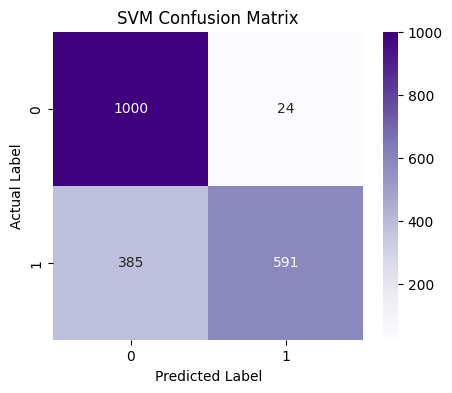


ROC Curve not plotted: SVC requires probability=True for predict_proba


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# SVM Predictions
y_test_pred_svm = y_test_svm
svm_model = svm

# Performance Metrics
precision_svm = precision_score(y_test, y_test_pred_svm)
recall_svm = recall_score(y_test, y_test_pred_svm)
f1_svm = f1_score(y_test, y_test_pred_svm)

# ROC-AUC (Not available unless SVC is initialized with probability=True)
roc_auc_svm = "N/A (probability=False in SVC)"

# Results
print("=== SVM Performance Metrics ===")
print(f"Training Accuracy : {acc_train_svm:.3f}")
print(f"Testing Accuracy  : {acc_test_svm:.3f}")
print(f"Precision         : {precision_svm:.3f}")
print(f"Recall            : {recall_svm:.3f}")
print(f"F1 Score          : {f1_svm:.3f}")
print(f"ROC-AUC Score     : {roc_auc_svm}")
print(f"Training Time     : {training_time_svm:.3f} seconds")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

print("\nROC Curve not plotted: SVC requires probability=True for predict_proba")


**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('SVM', acc_train_svm, acc_test_svm)

## **8. Comparision of Models**
To compare the models performance, a dataframe is created. The columns of this dataframe are the lists created to store the results of the model.

In [ ]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,Decision Tree,0.814,0.809
1,Random Forest,0.818,0.815
2,XGBoost,0.866,0.870
3,SVM,0.804,0.795


In [ ]:
#Sorting the datafram on accuracy
results.drop_duplicates(inplace=True) # Remove duplicate rows
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
2,XGBoost,0.866,0.870
1,Random Forest,0.818,0.815
0,Decision Tree,0.814,0.809
3,SVM,0.804,0.795


For the above comparision, it is clear that the XGBoost Classifier works well with this dataset.

So, saving the model for future use.

In [ ]:
# save XGBoost model to file
import pickle
pickle.dump(xgb, open("XGBoostClassifier.pickle.dat", "wb"))

**Testing the saved model:**

In [ ]:
# load model from file
loaded_model = pickle.load(open("XGBoostClassifier.pickle.dat", "rb"))
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## **9. References**
* https://blog.keras.io/building-autoencoders-in-keras.html
* https://en.wikipedia.org/wiki/Autoencoder
* https://mc.ai/a-beginners-guide-to-build-stacked-autoencoder-and-tying-weights-with-it/
* https://github.com/shreyagopal/t81_558_deep_learning/blob/master/t81_558_class_14_03_anomaly.ipynb
* https://machinelearningmastery.com/save-gradient-boosting-models-xgboost-python/